In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

In [2]:
# 创建数据
X,y = make_circles(n_samples=300,noise=0.05,factor=0.5,random_state=42)

# 标签
y = np.where(y == 0, -1 , 1)

In [3]:
# 标准化数据
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [4]:
# 为了让线性SVM能切开环形数据，我们需要手动给它做高维映射
# 增加一个新特征：x1**2 + x2** 即点到原点的距离平方，把数据顶到三维空间
X_projected = np.hstack((X,(X[:,0]**2 + X[:,1]**2).reshape(-1,1)))

In [5]:
X_projected

array([[-4.34359390e-01,  7.50485885e-01,  7.51897143e-01],
       [ 3.75379545e-01, -8.77075966e-01,  9.10172052e-01],
       [ 7.66562499e-01,  6.56578832e-02,  5.91929023e-01],
       [ 1.58007846e+00,  7.35938478e-01,  3.03825340e+00],
       [-8.43643728e-01, -3.10342244e-01,  8.08047049e-01],
       [-9.07618482e-01,  2.29138160e-02,  8.24296352e-01],
       [-3.53812220e-01,  8.96914070e-01,  9.29637937e-01],
       [-1.68938126e-01, -1.79557042e+00,  3.25261323e+00],
       [ 1.67012576e+00,  3.18479190e-01,  2.89074906e+00],
       [ 5.11191914e-01,  7.72670843e-01,  8.58337404e-01],
       [-7.29891974e-01, -2.77320168e-01,  6.09648770e-01],
       [-1.28712740e+00,  1.13987478e+00,  2.95601143e+00],
       [-7.64209545e-01,  2.55911049e-01,  6.49506694e-01],
       [-4.76611659e-01,  1.78062282e+00,  3.39777631e+00],
       [ 1.18006299e-01,  9.82988674e-01,  9.80192220e-01],
       [-8.03573478e-01,  8.89153539e-02,  6.53636275e-01],
       [ 8.29592873e-01, -3.78211890e-01

In [6]:
# 手写版本
# 。。。。。。
class MyLinearSVM:
    def __init__(self,learning_rate = 0.001,lambda_param = 0.01,n_iters = 1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.W = None
        self.b = None

    def fit(self,X,y):
        n_samples,n_features = X.shape
        # 随机或零初始化参数w和b
        self.w = np.zeros(n_features)
        self.b = 0

        # 优化算法：梯度下降循环
        for _ in range(self.n_iters):
            for idx,x_i in enumerate(X):
                condition = y[idx] * (np.dot(x_i,self.w) + self.b) >= 1
                if condition:
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    self.w -= self.lr * (2 * self.lambda_param * self.w - y[idx] * x_i)
                    self.b -= self.lr * (-y[idx])

    def predict(self,X):
        approx = np.dot(X,self.w) + self.b
        return np.sign(approx)


my_svm = MyLinearSVM(learning_rate=0.001,lambda_param=0.01,n_iters=1000)
my_svm.fit(X_projected,y)

In [7]:
# 官方使用了对偶算法和核技巧，不需要手动拼特征，直接传原始二维数组
clf = SVC(kernel='rbf',C=1.0)
clf.fit(X,y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


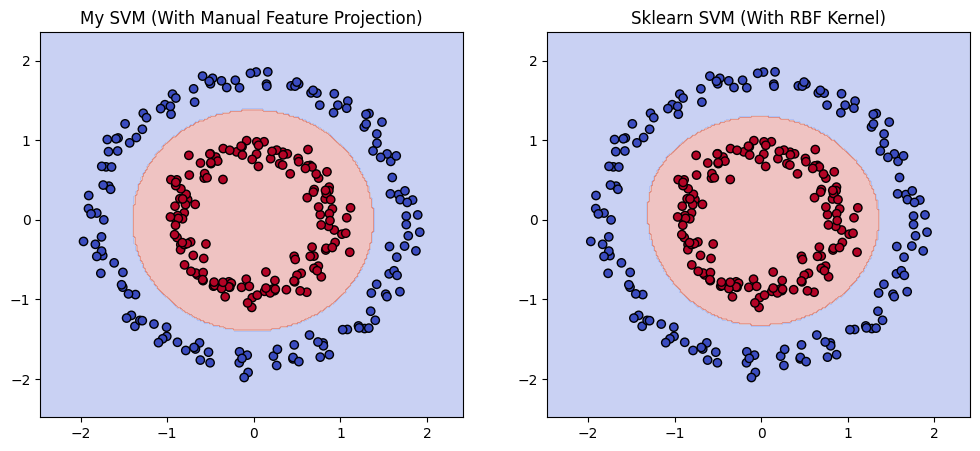

In [8]:
# 可视化对比结果
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 绘制手写 SVM 的决策边界
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

# 将网格点也做同样的三维特征映射
grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_projected = np.c_[grid_points, grid_points[:, 0]**2 + grid_points[:, 1]**2]
Z1 = my_svm.predict(grid_projected).reshape(xx.shape)

ax1.contourf(xx, yy, Z1, alpha=0.3, cmap=plt.cm.coolwarm)
ax1.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
ax1.set_title("My SVM (With Manual Feature Projection)")

# 绘制 Sklearn RBF SVM 的决策边界
Z2 = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax2.contourf(xx, yy, Z2, alpha=0.3, cmap=plt.cm.coolwarm)
ax2.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
ax2.set_title("Sklearn SVM (With RBF Kernel)")

plt.show()